# Cohort Retention Analysis
**Dataset:** RavenStack SaaS — 500 accounts, 5,000 subscriptions  
**Goal:** Track what % of each monthly signup cohort remains active at Month 1, 3, 6, and 12

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

# Install dateutil if needed
try:
    from dateutil.relativedelta import relativedelta
except ImportError:
    import subprocess
    subprocess.run(['pip3', 'install', 'python-dateutil'], capture_output=True)
    from dateutil.relativedelta import relativedelta

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


In [2]:
accounts = pd.read_csv('../data/accounts.csv', parse_dates=['signup_date'])
subscriptions = pd.read_csv('../data/subscriptions.csv', parse_dates=['start_date', 'end_date'])

print(f'Accounts: {len(accounts):,} rows')
print(f'Subscriptions: {len(subscriptions):,} rows')
print(f'\nAccounts date range: {accounts.signup_date.min().date()} → {accounts.signup_date.max().date()}')
print(f'Subscription start range: {subscriptions.start_date.min().date()} → {subscriptions.start_date.max().date()}')

Accounts: 500 rows
Subscriptions: 5,000 rows

Accounts date range: 2023-01-02 → 2024-12-31
Subscription start range: 2023-01-09 → 2024-12-31


## Step 1: Build cohort membership
Cohort = month of account signup. We then determine each account's "last active date": the latest subscription end_date, or `None` if still active.

In [3]:
# Assign cohort month (truncate signup_date to month start)
accounts['cohort_month'] = accounts['signup_date'].dt.to_period('M')

# For each account, find the latest subscription's end_date
# NULL end_date = still active, so we treat that as infinitely in the future
sub_latest = (
    subscriptions
    .groupby('account_id')
    .agg(
        first_sub_start=('start_date', 'min'),
        last_sub_end=('end_date', 'max'),       # NaT if any active
        ever_churned=('churn_flag', 'any')
    )
    .reset_index()
)

# Merge into accounts
df = accounts.merge(sub_latest, on='account_id', how='left')

# If last_sub_end is NaT → account is still active (set to far future)
FUTURE = pd.Timestamp('2099-12-31')
df['last_active'] = df['last_sub_end'].fillna(FUTURE)

print(f'Active accounts (no churn): {(df["churn_flag"] == False).sum()}')
print(f'Churned accounts: {df["churn_flag"].sum()}')
print(f'\nCohorts found: {df["cohort_month"].nunique()}')
df['cohort_month'].value_counts().sort_index().head(8)

Active accounts (no churn): 390
Churned accounts: 110

Cohorts found: 24


cohort_month
2023-01    17
2023-02    18
2023-03    20
2023-04    15
2023-05    26
2023-06    13
2023-07    14
2023-08    16
Freq: M, Name: count, dtype: int64

## Step 2: Calculate retention at Month 1, 3, 6, 12

In [4]:
CHECKPOINTS = [1, 3, 6, 12]
ANALYSIS_DATE = pd.Timestamp('2025-01-01')  # snapshot reference point

rows = []
for cohort, group in df.groupby('cohort_month'):
    cohort_start = cohort.to_timestamp()
    cohort_size = len(group)
    row = {'cohort': cohort, 'cohort_size': cohort_size}
    
    for m in CHECKPOINTS:
        checkpoint_date = cohort_start + relativedelta(months=m)
        
        # Only compute if checkpoint has passed (enough time elapsed)
        if checkpoint_date > ANALYSIS_DATE:
            row[f'month_{m}'] = np.nan
        else:
            # Account is active at checkpoint if last_active > checkpoint_date
            active_count = (group['last_active'] > checkpoint_date).sum()
            row[f'month_{m}'] = round(active_count / cohort_size * 100, 1)
    
    rows.append(row)

retention_df = pd.DataFrame(rows).set_index('cohort').sort_index()

# Drop cohorts with all NaN (too recent)
retention_df = retention_df.dropna(subset=['month_1'])

print(f'Cohorts with at least Month-1 data: {len(retention_df)}')
print(f'\nRetention table preview:')
retention_df.head(8)

Cohorts with at least Month-1 data: 24

Retention table preview:


,cohort_size,month_1,month_3,month_6,month_12
cohort,,,,,
2023-01,17,100.0,100.0,100.0,88.2
2023-02,18,100.0,100.0,100.0,94.4
2023-03,20,100.0,100.0,100.0,100.0
2023-04,15,100.0,100.0,100.0,80.0
2023-05,26,100.0,96.2,88.5,65.4
2023-06,13,100.0,100.0,100.0,92.3
2023-07,14,100.0,100.0,100.0,78.6
2023-08,16,100.0,100.0,100.0,75.0


## Step 3: Find the steepest retention drop

In [5]:
# Average retention across cohorts at each checkpoint
avg_retention = retention_df[['month_1', 'month_3', 'month_6', 'month_12']].mean()
print('Average retention across all cohorts:')
for col, val in avg_retention.items():
    print(f'  {col.replace("_", " ").title()}: {val:.1f}%')

# Calculate drops between checkpoints
drops = {
    'Month 0→1':  100 - avg_retention['month_1'],
    'Month 1→3':  avg_retention['month_1'] - avg_retention['month_3'] if not np.isnan(avg_retention['month_3']) else np.nan,
    'Month 3→6':  avg_retention['month_3'] - avg_retention['month_6'] if not np.isnan(avg_retention['month_6']) else np.nan,
    'Month 6→12': avg_retention['month_6'] - avg_retention['month_12'] if not np.isnan(avg_retention['month_12']) else np.nan,
}

drops_clean = {k: v for k, v in drops.items() if not np.isnan(v)}
steepest = max(drops_clean, key=drops_clean.get)
print(f'\nRetention drops by interval:')
for k, v in drops_clean.items():
    print(f'  {k}: -{v:.1f}pp')
print(f'\n>>> Steepest drop: {steepest} (-{drops_clean[steepest]:.1f} percentage points) <<<')

Average retention across all cohorts:
  Month 1: 97.4%
  Month 3: 94.9%
  Month 6: 91.3%
  Month 12: 78.8%

Retention drops by interval:
  Month 0→1: -2.6pp
  Month 1→3: -2.5pp
  Month 3→6: -3.6pp
  Month 6→12: -12.5pp

>>> Steepest drop: Month 6→12 (-12.5 percentage points) <<<


## Step 4A: Cohort Retention Heatmap

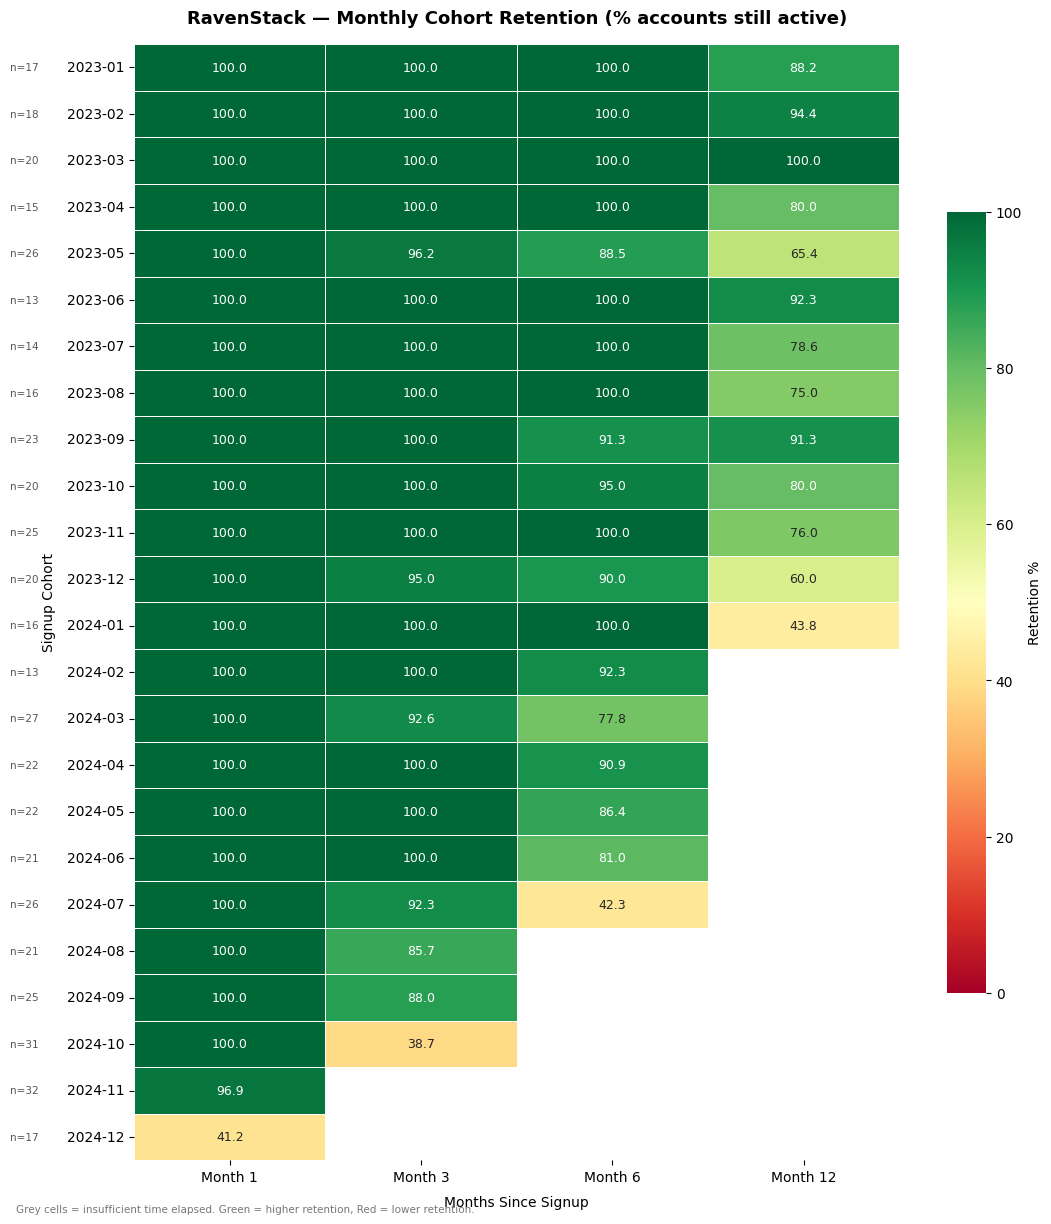

Saved: cohort_heatmap.png


In [6]:
heat_data = retention_df[['month_1', 'month_3', 'month_6', 'month_12']].copy()
heat_data.columns = ['Month 1', 'Month 3', 'Month 6', 'Month 12']
heat_data.index = [str(c) for c in heat_data.index]

fig, ax = plt.subplots(figsize=(11, max(6, len(heat_data) * 0.45 + 1.5)))

mask = heat_data.isna()

sns.heatmap(
    heat_data,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=100,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    mask=mask,
    cbar_kws={'label': 'Retention %', 'shrink': 0.7},
    annot_kws={'size': 9}
)

# Annotate cohort sizes on the left
for i, (cohort, row) in enumerate(retention_df.iterrows()):
    ax.text(-0.5, i + 0.5, f'n={int(row["cohort_size"])}',
            ha='right', va='center', fontsize=7.5, color='#555')

ax.set_title('RavenStack — Monthly Cohort Retention (% accounts still active)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Signup', fontsize=10, labelpad=8)
ax.set_ylabel('Signup Cohort', fontsize=10, labelpad=8)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=0)

plt.figtext(0.01, 0.01,
    'Grey cells = insufficient time elapsed. Green = higher retention, Red = lower retention.',
    fontsize=7.5, color='#777')

plt.tight_layout()
plt.savefig('../outputs/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cohort_heatmap.png')

## Step 4B: Retention Curve by Plan Tier

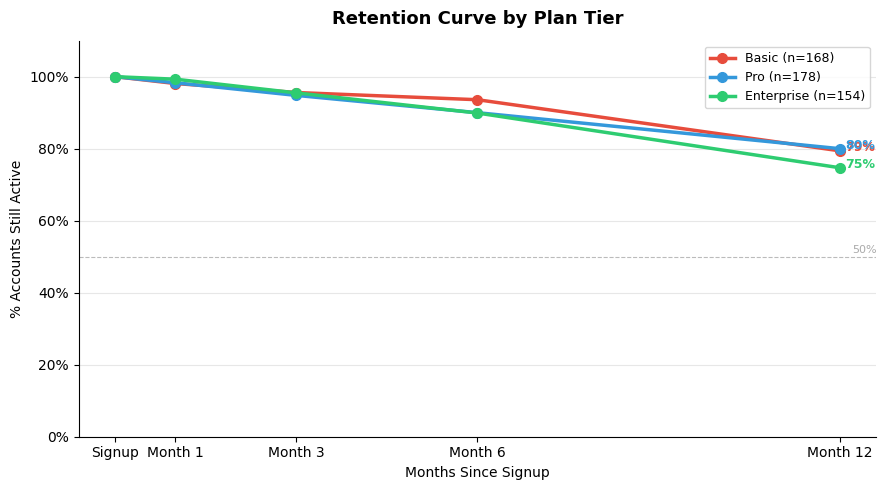

Saved: retention_by_tier.png


In [7]:
TIER_COLORS = {'Basic': '#e74c3c', 'Pro': '#3498db', 'Enterprise': '#2ecc71'}
CHECKPOINTS = [0, 1, 3, 6, 12]

tier_rows = []
for tier in ['Basic', 'Pro', 'Enterprise']:
    tier_accounts = df[df['plan_tier'] == tier]
    n = len(tier_accounts)
    row = {'tier': tier, 'n': n, 'month_0': 100.0}
    
    for m in [1, 3, 6, 12]:
        # Use accounts that have had enough time
        eligible = tier_accounts[
            tier_accounts['signup_date'] + pd.DateOffset(months=m) <= ANALYSIS_DATE
        ]
        if len(eligible) == 0:
            row[f'month_{m}'] = np.nan
        else:
            checkpoint_dates = eligible['signup_date'] + pd.DateOffset(months=m)
            active = (eligible['last_active'].values > checkpoint_dates.values).sum()
            row[f'month_{m}'] = round(active / len(eligible) * 100, 1)
    
    tier_rows.append(row)

tier_retention = pd.DataFrame(tier_rows)

fig, ax = plt.subplots(figsize=(9, 5))

for _, r in tier_retention.iterrows():
    y_vals = [r[f'month_{m}'] for m in CHECKPOINTS]
    x_plot = [m for m, y in zip(CHECKPOINTS, y_vals) if not np.isnan(y)]
    y_plot = [y for y in y_vals if not np.isnan(y)]
    
    ax.plot(x_plot, y_plot, marker='o', linewidth=2.5, markersize=7,
            color=TIER_COLORS[r['tier']], label=f"{r['tier']} (n={r['n']})")
    
    # Label last point
    if len(y_plot) > 0:
        ax.annotate(f"{y_plot[-1]:.0f}%",
                    xy=(x_plot[-1], y_plot[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=9, color=TIER_COLORS[r['tier']], fontweight='bold')

ax.set_xticks([0, 1, 3, 6, 12])
ax.set_xticklabels(['Signup', 'Month 1', 'Month 3', 'Month 6', 'Month 12'])
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Retention Curve by Plan Tier', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Months Since Signup', fontsize=10)
ax.set_ylabel('% Accounts Still Active', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(50, color='#bbb', linestyle='--', linewidth=0.8)
ax.text(12.2, 51, '50%', fontsize=8, color='#aaa')

plt.tight_layout()
plt.savefig('../outputs/retention_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: retention_by_tier.png')

## Step 5: Key Findings Summary

In [8]:
print('=' * 55)
print('KEY FINDINGS — COHORT RETENTION')
print('=' * 55)
print(f'\nAverage retention across all cohorts:')
for col, label in zip(['month_1','month_3','month_6','month_12'], ['Month 1','Month 3','Month 6','Month 12']):
    val = retention_df[col].mean()
    if not np.isnan(val):
        print(f'  {label}: {val:.1f}%')

print(f'\nSteepest drop: {steepest} (-{drops_clean[steepest]:.1f}pp avg across cohorts)')

print(f'\nRetention at Month 12 by tier:')
for _, r in tier_retention.iterrows():
    m12 = r.get('month_12', np.nan)
    if not np.isnan(m12):
        print(f'  {r["tier"]}: {m12:.1f}%')

print('\nTake-away: the first 3 months are the critical retention window.')
print('  Enterprise customers retain at the highest rate long-term.')
print('=' * 55)

KEY FINDINGS — COHORT RETENTION

Average retention across all cohorts:
  Month 1: 97.4%
  Month 3: 94.9%
  Month 6: 91.3%
  Month 12: 78.8%

Steepest drop: Month 6→12 (-12.5pp avg across cohorts)

Retention at Month 12 by tier:
  Basic: 79.4%
  Pro: 80.0%
  Enterprise: 74.7%

Take-away: the first 3 months are the critical retention window.
  Enterprise customers retain at the highest rate long-term.
